# PCHN63112 Workshop: Clustered Longitudinal Data Example
In this example,we will examine building a mixed-effects model for longitudinal data that are also clustered. This will demonstrate how the multilevel framework extends beyond two levels, as well as how this can be integrated into a mixed-effects model. This is also a larger example, especially when interactions are considered. This will lead to a more complex expression for the model, but one which is a simple generalisation of other examples we have seen. Of particular importance is that this example shows a model where *all* the variables are continuous. This will be an important bridge before seeing examples that are a *mixture* of categorical and continuous.

## Loading Packages
We will start by loading all the packages that we need at the beginning. This will tidy-up the output, allow any messages or warnings to not clutter up the rest of the output and not bury any packages within the main body of the analysis. We also use `source()` on the file `plot-lme.R`. This needs to be in the current working directory and will bring the custom function `plot.lme()` into scope.

In [1]:
library('lattice')   # plotting functions
library('Matrix')    # covariance extraction and visualisation
library('nlme')      # mixed-effects modelling
library('car')       # Asymptotic ANOVA tests
library('emmeans')   # Follow-up tests
library('effects')   # Effects plots from the model
source('plot-lme.R') # custom plot.lme() function for making assumptions plots

Loading required package: carData
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'
Use the command
    lattice::trellis.par.set(effectsTheme())
  to customize lattice options for effects plots.
See ?effectsTheme for details.


## The Dental Veneer Data
The data we will use concern measurements of ...

The data can be downloaded from [here](https://websites.umich.edu/~bwest/chapter7.html). Once downloaded to the current working directory, the code below will read the data into `R` and then print values for all the teeth from the first two patients. 

In [2]:
veneer <- read.table('veneer.dat', header=TRUE)
veneer[1:24,]

   patient tooth age base_gcf       cda time gcf
1        1     6  46       17  4.666667    3  11
2        1     6  46       17  4.666667    6  68
3        1     7  46       22  4.666667    3  13
4        1     7  46       22  4.666667    6  47
5        1     8  46       18  5.000000    3  14
6        1     8  46       18  5.000000    6  58
7        1     9  46       12  3.333333    3  10
8        1     9  46       12  3.333333    6  57
9        1    10  46       10  8.666667    3  14
10       1    10  46       10  8.666667    6  44
11       1    11  46       17  5.666667    3  11
12       1    11  46       17  5.666667    6  53
13       3     6  32        3  7.666667    3  28
14       3     6  32        3  7.666667    6  23
15       3     7  32        4 11.000000    3  17
16       3     7  32        4 11.000000    6  15
17       3     8  32        3 10.666670    3  19
18       3     8  32        3 10.666670    6  32
19       3     9  32       10 10.000000    3  34
20       3     9  32

There are a few variables here, so we split them into those that relate to each *patient* as a whole, each *tooth* as a whole and each *time-point* as a whole.

- Patient
    - `patient`: the unique identifier of each *patient*
    - `age`: the patient's age
- Tooth
    - `tooth`: the unique identifier of each *tooth*
    - `based_cdf`: the baseline measure of GCF for that tooth
    - `cda`: the ... for that tooth
- Time
    - `time`: the time in months after fitting the veneer
    - `gcf`: **the measurement of GCF at that time point**

Some of these variables are indices to keep things organised and to allow us to define different levels of the data. Notable, `patient` and `tooth`. The outcome variable is `gcf`, highlighted in **bold**, indicative of ... . This leaves *four* predictor variables, as well as several opportunities for *interactions*.

As these data are already long-formatted, we just need to convert the relevant variables to factors.

In [3]:
veneer$patient <- as.factor(veneer$patient)
veneer$tooth   <- as.factor(veneer$tooth)

We can now briefly summarise all the variables. At this stage, we would usually produce some plots and do further data checking and wrangling, but we will leave this step to one side to keep the example shorter.

In [4]:
summary(veneer)

    patient   tooth        age           base_gcf          cda              time          gcf       
 1      :12   6 :16   Min.   :21.00   Min.   : 3.00   Min.   :-3.000   Min.   :3.0   Min.   : 3.00  
 3      :12   7 :20   1st Qu.:29.00   1st Qu.:10.00   1st Qu.: 3.417   1st Qu.:3.0   1st Qu.:10.00  
 4      :12   8 :20   Median :46.00   Median :15.00   Median : 5.000   Median :4.5   Median :17.50  
 6      :12   9 :18   Mean   :39.87   Mean   :17.38   Mean   : 5.182   Mean   :4.5   Mean   :23.59  
 7      :12   10:22   3rd Qu.:50.75   3rd Qu.:25.00   3rd Qu.: 7.250   3rd Qu.:6.0   3rd Qu.:32.00  
 8      :12   11:14   Max.   :62.00   Max.   :42.00   Max.   :11.000   Max.   :6.0   Max.   :87.00  
 (Other):38                                                                                         

Of note is that there are unbalanced representations of each level of `tooth`, ...

### Model Notation
As these data are all *continuous* variables, a more general regression framework will be needed when writing this model. In what follows, we will use $\beta$-coefficients for continuous variables (e.g. $\beta_{1} \times \text{CDA}_{i}$ rather than $\beta_{1}x_{i1}$). This should hopefully make it clearer which variable each term relates to when writing the model down.

## Data Structure
Although we already know what structure these data have, we will run through the logic for completeness.

Firstly, we need to determine our *unit of analysis*. In this example, ... From the perspective of a psychologist, this can sound off. However, remember that dentists care about *teeth* and not necessarily the person that the teeth belong to.

Secondly, we determine what each *row* of the long-formatted data represents in relation to the units of analysis. Examining the first few rows

In [5]:
head(veneer)

  patient tooth age base_gcf      cda time gcf
1       1     6  46       17 4.666667    3  11
2       1     6  46       17 4.666667    6  68
3       1     7  46       22 4.666667    3  13
4       1     7  46       22 4.666667    6  47
5       1     8  46       18 5.000000    3  14
6       1     8  46       18 5.000000    6  58

...

Based on this, we can construct the following table of the *levels* of these data, using the guidance in the lesson

| **Data Type**    | **Clustered Longitudinal** | 
|------------------|----------------------------|
| **Dataset**      | `veneer`                   |
| **Level 1**      | Time                       |
| **Level 2**      | *Tooth*                    |
| **Level 3**      | Patient                    |


## Model Building
To build a model of this dataset, we use the 3-step procedure outlined in the lesson. We assume at this point that the data has been investigated, wrangled, cleaned and ready for modelling.

### Step I: A Single Dependency Structure
We start by isolating a single dependency structure. This needs to be at the *lowest* level, with no further dependency structures within. In this example, this is a single *tooth* from a single *patient*. We choose `tooth == '6'` within `patient == '1'` for this purpose.

In [6]:
patient.1 <- subset(veneer,    patient == '1')
tooth.6   <- subset(patient.1, tooth   == '6')

print(tooth.6)

  patient tooth age base_gcf      cda time gcf
1       1     6  46       17 4.666667    3  11
2       1     6  46       17 4.666667    6  68


In [7]:
tooth.6 <- subset(patient.1, tooth == '6', select=c(-patient,-age,-base_gcf,-cda))
print(tooth.6)

  tooth time gcf
1     6    3  11
2     6    6  68


Based on this, our basic model for a single tooth is

$$
\text{GCF}_{i} = \beta_{0} + (\beta_{1} \times \text{time}_{i}) + \eta_{i}
$$

where $i$ indexes *time*. Already, a problem should be visible. As we only have two measurements per-tooth, the model fit will be perfect and there will be no residual variance left.

In [8]:
tooth.6.lm <- lm(gcf ~ 1 + time, data=tooth.6)
summary(tooth.6.lm)


Call:
lm(formula = gcf ~ 1 + time, data = tooth.6)

Residuals:
ALL 2 residuals are 0: no residual degrees of freedom!

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)      -46        NaN     NaN      NaN
time              19        NaN     NaN      NaN

Residual standard error: NaN on 0 degrees of freedom
Multiple R-squared:      1,	Adjusted R-squared:    NaN 
F-statistic:   NaN on 1 and 0 DF,  p-value: NA


This means that we will not be able to estimate a unique effect of `time` for each tooth from each `patient`. Instead, we will need to *pool* information *across* patients. This is a constraint of the data that we will need to bear in mind.

### Step II: Expand to Multiple Structures
In our second step, we expand the model above to *multiple* teeth from the same patient. We index these using the notation of $(t)$, to indicate which terms *belong* to a particular *tooth*. We start with the most general case of allowing every term to vary by-tooth, giving us

$$
\text{GCF}^{(t)}_{i} = \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}.
$$

We can now reason more carefully about each of these.



In [9]:
print(patient.1)

   patient tooth age base_gcf      cda time gcf
1        1     6  46       17 4.666667    3  11
2        1     6  46       17 4.666667    6  68
3        1     7  46       22 4.666667    3  13
4        1     7  46       22 4.666667    6  47
5        1     8  46       18 5.000000    3  14
6        1     8  46       18 5.000000    6  58
7        1     9  46       12 3.333333    3  10
8        1     9  46       12 3.333333    6  57
9        1    10  46       10 8.666667    3  14
10       1    10  46       10 8.666667    6  44
11       1    11  46       17 5.666667    3  11
12       1    11  46       17 5.666667    6  53


### Step III: Write the Higher-level Models
Now that we have made a decision about all the Level 1 terms, we can write the Level 2 models for each term...

$$
\begin{alignat*}{1}
\text{Level 1 (Time)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta_{0} + \left(\beta_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta_{1} \\
\end{alignat*}
$$

... we can add interactions with the effect of time in the model for $\beta^{(t)}_{1}$ ...

$$
\begin{alignat*}{1}
\text{Level 1 (Time)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta_{0} + \left(\beta_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta_{1} + \left(\beta_{4} \times \text{GCFb}^{(t)}\right) + \left(\beta_{5} \times \text{CDA}^{(t)}\right)  \\
\end{alignat*}
$$

#### Expand to Multiple Patients

$$
\begin{alignat*}{1}
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta^{(p)}_{0} + \left(\beta^{(p)}_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta^{(p)}_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta^{(p)}_{1} + \left(\beta^{(p)}_{4} \times \text{GCFb}^{(t)}\right) + \left(\beta^{(p)}_{5} \times \text{CDA}^{(t)}\right) \\ \quad \\
\text{Level 3 (Patient)} \\
    \beta^{(p)}_{0} &= \beta_{0} + \left(\beta_{6} \times \text{age}^{(p)}\right) + \phi_{0}^{(p)} \\
    \beta^{(p)}_{1} &= \beta_{1} + \left(\beta_{7} \times \text{age}^{(p)}\right) + \phi_{1}^{(p)} \\
    \beta^{(p)}_{2} &= \beta_{2}  \\
    \beta^{(p)}_{3} &= \beta_{3} \\
    \beta^{(p)}_{4} &= \beta_{4} \\
    \beta^{(p)}_{5} &= \beta_{5} 
\end{alignat*}
$$

... The full model is

$$
\begin{alignat*}{1}
\text{Level 1 (Time)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta^{(p)}_{0} + \left(\beta^{(p)}_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta^{(p)}_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta^{(p)}_{1} + \left(\beta^{(p)}_{4} \times \text{GCFb}^{(t)}\right) + \left(\beta^{(p)}_{5} \times \text{CDA}^{(t)}\right) \\ \quad \\
\text{Level 3 (Patient)} \\
    \beta^{(p)}_{0} &= \beta_{0} + \left(\beta_{6} \times \text{age}^{(p)}\right) + \phi_{0}^{(p)} \\
    \beta^{(p)}_{1} &= \beta_{1} + \left(\beta_{7} \times \text{age}^{(p)}\right) + \phi_{1}^{(p)} \\
    \beta^{(p)}_{2} &= \beta_{2}  \\
    \beta^{(p)}_{3} &= \beta_{3} \\
    \beta^{(p)}_{4} &= \beta_{4} \\
    \beta^{(p)}_{5} &= \beta_{5} 
\end{alignat*}
$$

which we can simplify by collapsing the fixed-effects back into the different levels to give

$$
\begin{alignat*}{1}
\text{Level 1 (Time)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(p)}_{1} \times \text{time}_{i}\right) + \left(\beta_{4} \times \text{GCFb}^{(t)} \times \text{time}_{i}\right) + \left(\beta_{5} \times \text{CDA}^{(t)} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta^{(p)}_{0} + \left(\beta_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\ \quad \\
\text{Level 3 (Patient)} \\
    \beta^{(p)}_{0} &= \beta_{0} + \left(\beta_{6} \times \text{age}^{(p)}\right) + \phi_{0}^{(p)} \\
    \beta^{(p)}_{1} &= \beta_{1} + \left(\beta_{7} \times \text{age}^{(p)}\right) + \phi_{1}^{(p)} \\
\end{alignat*}
$$

## Fitting the Model in `R`

$$
\begin{alignat*}{1}
    \text{GCF}^{(t)}_{i} = &\: \beta_{0} + \left(\beta_{1} \times \text{time}_{i}\right) + \left(\beta_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta_{3} \times \text{CDA}^{(t)}\right) + \left(\beta_{6} \times \text{age}^{(p)}\right) + \\ 
    &\left(\beta_{4} \times \text{GCFb}^{(t)} \times \text{time}_{i}\right) + \left(\beta_{5} \times \text{CDA}^{(t)} \times \text{time}_{i}\right) + \left(\beta_{7} \times \text{age}^{(p)} \times \text{time}_{i}\right) + \\
    &\xi_{0}^{(t)} + \phi_{0}^{(p)} + \left(\phi_{1}^{(p)} \times \text{time}_{i}\right) + \eta^{(t)}_{i} 
\end{alignat*}
$$

which does look quite complicated, but consists of an intercept $(\beta_{0})$; slopes with `time` $(\beta_{1})$, `baseline_GCF` $(\beta_{2})$, `CDA` $(\beta_{3})$ and `age` $(\beta_{6})$; interactions `baseline_GCF:time` $(\beta_{4})$, `CDA:time` $(\beta_{5})$ and `age:time` $(\beta_{7})$; a random intercept per-tooth $\left(\xi_{0}^{(t)}\right)$, a random intercept and `time` slope per-patient $\left(\phi_{0}^{(p)}, \phi_{1}^{(p)}\right)$ and a final error term $\left(\eta^{(t)}_{i}\right)$.

In terms of specifying this in `R`, the fixed-effects are straightforward as the description above leads to `fixed = gcf ~ 1 + base_gcf + cda + time + age + time:base_gcf + time:cda + time:age`. For the random effects, we start with the error terms

$$
\xi_{0}^{(t)} + \phi_{0}^{(p)} + \left(\phi_{1}^{(p)} \times \text{time}_{i}\right) + \eta^{(t)}_{i}
$$

and then remove the final errors, as they do not need to be explicitly specified.

$$
\xi_{0}^{(t)} + \phi_{0}^{(p)} + \left(\phi_{1}^{(p)} \times \text{time}_{i}\right).
$$

We then change the conditional notation to give

$$
\begin{alignat*}{1}
    \xi_{0} &\:|\: t \\
    \phi_{0} + \left(\phi_{1} \times \text{time}_{i}\right) &\:|\: p \\
\end{alignat*}
$$

implying that we need both `1|tooth` and `1 + time|patient` in the model. 

How do we do this? The way `lme()` handles this situation is by passing a `list` to the `random=` option. Within this list, we label each field using the relevant factor variable and then give the model formula. Due to the labelling, the conditional syntax is implied and does not need to be given explicitly. So, for both `1|tooth` and `1 + time|patient` we can use `list(tooth = ~ 1, patient = ~ 1 + age)`. This gives us full control of the random-effects specification at each level. Our model can therefore be expressed to `lme()` using the following syntax

In [10]:
veneer.lme <- lme(fixed   = gcf ~ 1 + base_gcf + cda + time + age + time:base_gcf + time:cda + time:age,
                  random  = list(tooth   = ~ 1,
                                 patient = ~ 1 + time),
                  data    = veneer, 
                  control = lmeControl(opt='optim') 
) 

which we can print to check

In [11]:
print(veneer.lme)

Linear mixed-effects model fit by REML
  Data: veneer 
  Log-restricted-likelihood: -459.1694
  Fixed: gcf ~ 1 + base_gcf + cda + time + age + time:base_gcf + time:cda +      time:age 
  (Intercept)      base_gcf           cda          time           age base_gcf:time      cda:time      time:age 
  88.89247933   -0.26927505   -2.30330590  -11.18323137   -1.30710933    0.05086456    0.62792054    0.19630363 

Random effects:
 Formula: ~1 | tooth
        (Intercept)
StdDev:    2.480235

 Formula: ~1 + time | patient %in% tooth
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev    Corr  
(Intercept) 18.708417 (Intr)
time         5.659124 -0.922
Residual     9.960779       

Number of Observations: 110
Number of Groups: 
             tooth patient %in% tooth 
                 6                 55 


In [12]:
Sigma.1 <- try(getVarCov(veneer.lme))

Error in getVarCov.lme(veneer.lme) : 
  not implemented for multiple levels of nesting


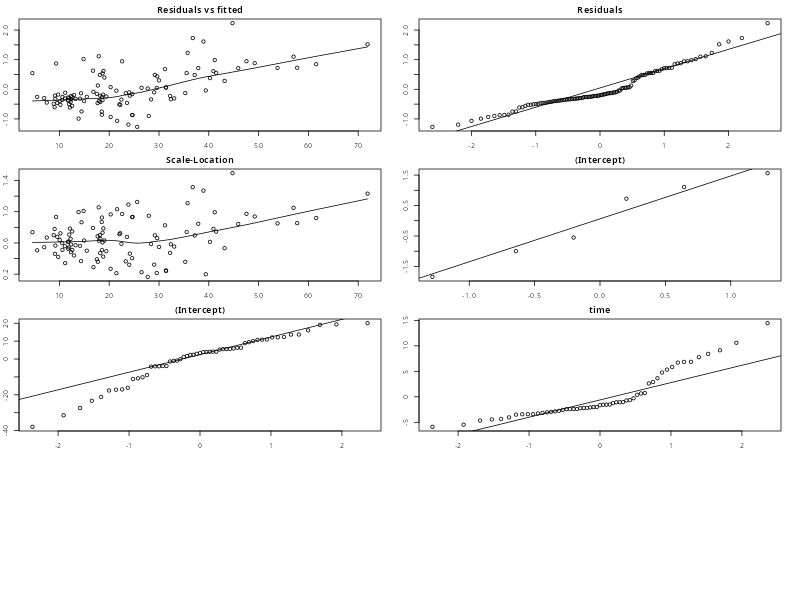

Warning message:
In plot.lme(veneer.lme) :
  Marginal covariance structure not available for more than 2 levels


In [13]:
plot.lme(veneer.lme)

In [14]:
vif(veneer.lme)

     base_gcf           cda          time           age base_gcf:time      cda:time      time:age 
     8.321834      8.480576     37.151996      7.962650     12.208380     12.435790     22.079264 

So, this looks like we have a *very* big problem with multicolinearity. Notice that the biggest culprit is between `time` and its interactions. Often, this can be down to using *un-centered* continuous variables. Centering (the act of removing the mean from each variable) helps separate-out the main effect from the interaction when using continuous variables. In doing so, we can dramatically reduce the overlap in the model terms. When working with models like this that contain continuous interactions, it is often a good idea to start by centering all the variables and see if this resolves the problem. In `R`, this can be done using   

In [15]:
veneer$base_gcf.c <- veneer$base_gcf - mean(veneer$base_gcf)
veneer$cda.c      <- veneer$cda      - mean(veneer$cda) 
veneer$time.c     <- veneer$time     - mean(veneer$time)
veneer$age.c      <- veneer$age      - mean(veneer$age)

veneer.lme <- lme(fixed   = gcf ~ 1 + base_gcf.c + cda.c + time.c + age.c + time.c:base_gcf.c + time.c:cda.c + time.c:age.c,
                  random  = list(tooth   = ~ 1,
                                 patient = ~ 1 + time.c),
                  data    = veneer, 
                  control = lmeControl(opt='optim') 
) 

vif(veneer.lme)

       base_gcf.c             cda.c            time.c             age.c base_gcf.c:time.c      cda.c:time.c      time.c:age.c 
         1.701232          1.754961          1.000000          1.604670          1.679292          1.732705          1.590532 

As we can see, the problem has now disappeared. Note, if there is still high VIF even *after* centering, then there is a more fundamental issue with the variables in question. Luckily, we do not have this here and so can continue without any other intervention.

## Inference

In [16]:
Anova(veneer.lme)

Analysis of Deviance Table (Type II tests)

Response: gcf
                    Chisq Df Pr(>Chisq)    
base_gcf.c         0.2222  1    0.63737    
cda.c              0.0006  1    0.97979    
time.c             0.6228  1    0.43000    
age.c             16.4971  1  4.872e-05 ***
base_gcf.c:time.c  0.2038  1    0.65168    
cda.c:time.c       2.7124  1    0.09957 .  
time.c:age.c       4.4178  1    0.03557 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Note that because these are all single degree-of-freedom tests, there is no need for any follow-up tests. These are not omnibus tests. Instead, these can be taken as asymptotic equivalents to the coefficients tests in the regression table. 

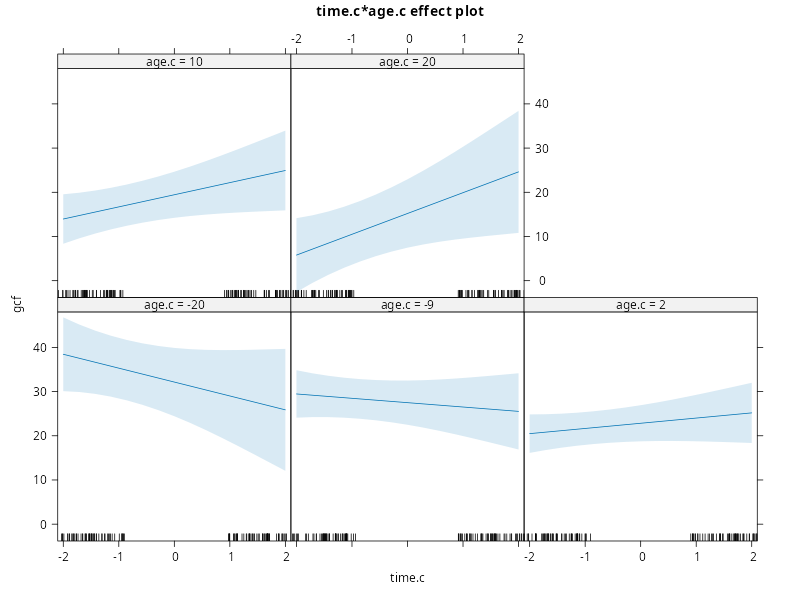

In [17]:
plot(effect('time.c:age.c', veneer.lme))

By default, when plotting a continuous x continuous interaction, the `effect()` function will choose 5 values of one predictor over which to display the slope of the other predictor. So, in this example, 5 values of `age` have been chosen to illustrate how the slope with `time` changes. This can be controlled using the `xlevels` argument, which we can set to a single value to control the number of equally-spaced values chosen. For instance, if we used `xlevels=20`, we would get

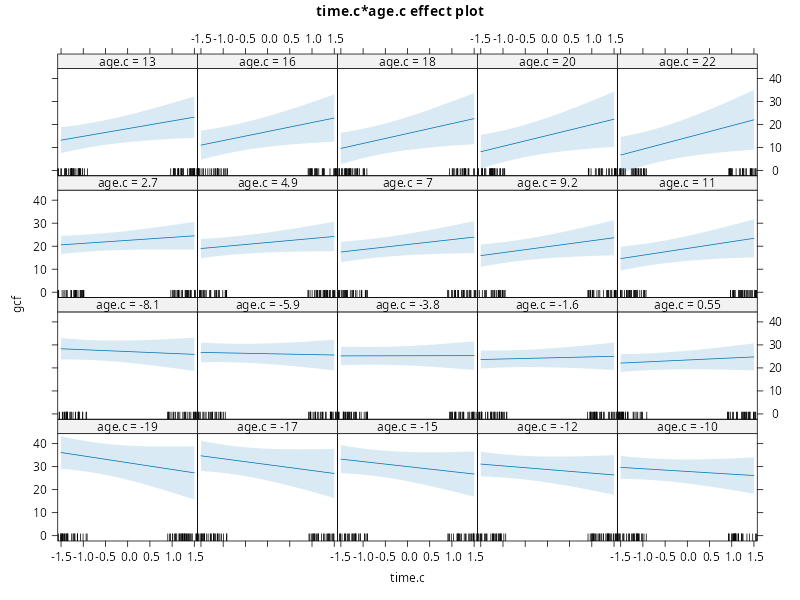

In [18]:
plot(effect('time.c:age.c', veneer.lme, xlevels=20))

The only problem we have here is that the plots are constructed on the *centered* scale, which is difficult to interpret in terms of the original scale of each variable. To accommodate this, we can calculate the effects first and then rescale them before plotting.

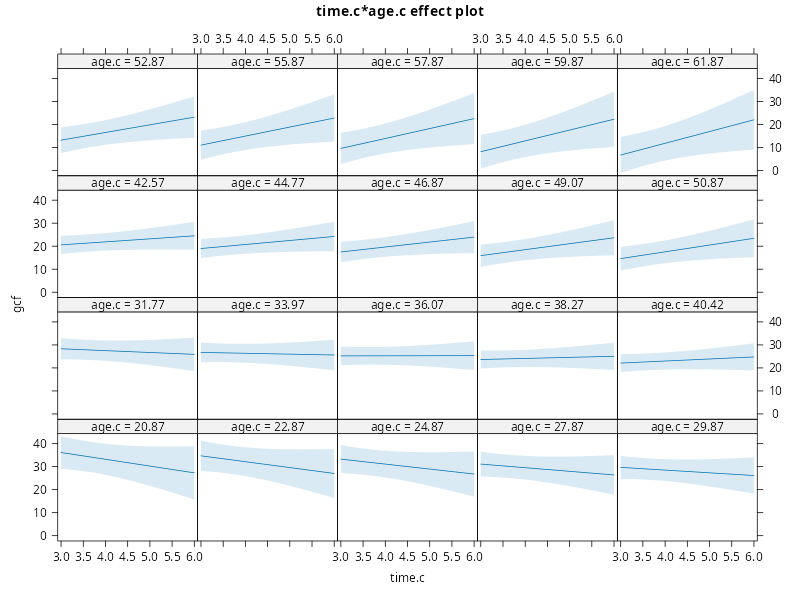

In [19]:
eff          <- effect('time.c:age.c', veneer.lme, xlevels=20)
eff$x$time.c <- round(eff$x$time.c + mean(veneer$time), 2) # add mean back in and round
eff$x$age.c  <- round(eff$x$age.c  + mean(veneer$age),  2) # add mean back in and round
plot(eff)

Now we can more easily see the effects on the original scale. The only *disadvantage* of doing this is that `effect` has chosen the 20 levels of `age` based on sensible rounded values on the *centered* scale, which does not necessarily equate to sensible rounded values on the *un-centered* scaled. So, we enm up with some weird values of `age` for each panel. We can provide `xlevels` with a list telling it which values to use for both variables, but we will leave that complexity to one side. Irrespective of the scaling, the result should be clear. As `age` increases, the slope with `time` slowly shifts from negative to positive. Patients in their 20s will show an average *decrease* in GCF over the course of 3 months. Patients in their 30s will show *no change* on average. However, patients aged 40 and above will start to show an *increase* in GCF over the course of 3 months, with this change becoming more pronounced the older they get.

The overall conclusion here is that 